In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
'''图片数据集载入'''
import torch
import torchvision
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
transform1 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform2 = transforms.Compose([
    transforms.Resize([150, 150]),
    transforms.RandomCrop([128, 128]), #随机裁剪
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform3 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomAffine(20),  #随机仿射变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform4 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomEqualize(0.9),  #概率直方图均衡
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform5 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomHorizontalFlip(p=1),  #水平翻转
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform6 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(brightness=(0.5, 2)),  #亮度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform7 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(contrast=(0.5, 2)),  #对比度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform8 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(saturation=(0.5, 2)),  #饱和度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
train_path ='/content/drive/MyDrive/yoga/yoga_pose_solo_splited/train'
test_path ='/content/drive/MyDrive/yoga/yoga_pose_solo_splited/test'
data1 = torchvision.datasets.ImageFolder(root=train_path,transform=transform1) 
data2 = torchvision.datasets.ImageFolder(root=train_path,transform=transform2)
data3 = torchvision.datasets.ImageFolder(root=train_path,transform=transform3)
data4 = torchvision.datasets.ImageFolder(root=train_path,transform=transform4)
data5 = torchvision.datasets.ImageFolder(root=train_path,transform=transform5)
data6 = torchvision.datasets.ImageFolder(root=train_path,transform=transform6)
data7 = torchvision.datasets.ImageFolder(root=train_path,transform=transform7)
data8 = torchvision.datasets.ImageFolder(root=train_path,transform=transform8)
trainset1 = data1+data2+data3+data4+data5+data6+data7+data8
testset1 = torchvision.datasets.ImageFolder(root=test_path,transform=transform1)
#print(trainset1[0])

In [4]:
'''骨架坐标点数据集载入'''
import pandas as pd
import numpy as np
df = pd.read_csv("/content/drive/MyDrive/yoga/landmarks/train_landmarks.csv",encoding='gbk')
df.loc[df['体式']=='downdog', '体式编号'] = 0
df.loc[df['体式']=='goddess', '体式编号'] = 1
df.loc[df['体式']=='lowcobra', '体式编号'] = 2
df.loc[df['体式']=='tree', '体式编号'] = 3
df.loc[df['体式']=='warrior2', '体式编号'] = 4
df.drop(["编号", '体式', '标准/不标准'],axis=1, inplace=True)
dataset_train = df.values
X_train = dataset_train[:,:-1].astype(float)
Y_train = dataset_train[:,-1:].astype(int).squeeze(-1)
X_train, Y_train = torch.Tensor(X_train),torch.LongTensor(Y_train) 
#print(X_train, Y_train)
df = pd.read_csv("/content/drive/MyDrive/yoga/landmarks/test_landmarks.csv",encoding='gbk')
df.loc[df['体式']=='downdog', '体式编号'] = 0
df.loc[df['体式']=='goddess', '体式编号'] = 1
df.loc[df['体式']=='lowcobra', '体式编号'] = 2
df.loc[df['体式']=='tree', '体式编号'] = 3
df.loc[df['体式']=='warrior2', '体式编号'] = 4
df.drop(["编号", '体式', '标准/不标准'],axis=1, inplace=True)
#df.drop(['体式', '标准/不标准'],axis=1, inplace=True)
dataset_test = df.values
X_test = dataset_test[:,:-1].astype(float)
Y_test = dataset_test[:,-1:].astype(int).squeeze(-1)
X_test, Y_test = torch.Tensor(X_test),torch.LongTensor(Y_test)
#print(X_test)
trainset2_data =  torch.utils.data.TensorDataset(X_train,Y_train)
trainset2 = trainset2_data+trainset2_data+trainset2_data+trainset2_data+trainset2_data+trainset2_data+trainset2_data+trainset2_data
testset2 = torch.utils.data.TensorDataset(X_test,Y_test)
#print(trainset2[0])

In [5]:
import torch.utils.data as data
class Mydataset(data.Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.idx = list()
        for item in x:
            self.idx.append(item)
        pass
    def __getitem__(self, index):
        input_data = self.idx[index] #可继续进行数据增强，这里没有进行数据增强操作
        target = self.y[index]
        return input_data, target
    def __len__(self):
        return len(self.idx)
trainset = torch.load("/content/drive/MyDrive/yoga/datasets/classification2_test5_trainset.pt")
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=32, shuffle=True)

In [6]:
testset = torch.load("/content/drive/MyDrive/yoga/datasets/classification2_test3_testset.pt")
testloader = torch.utils.data.DataLoader(
    testset, batch_size=128, shuffle=False)

In [7]:
'''MLP网络'''
import torch.nn as nn
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.all = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Dropout(p=0.5),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )
    def forward(self, x):
        out = self.all(x)
        return out

In [8]:
'''VGG19与MLP网络全连接层拼接网络'''
import torch.nn as nn
import torchvision.models as models
vgg19 = models.vgg19(pretrained=True)
vgg19.classifier = nn.Sequential(*list(vgg19.classifier.children())[:-1])  
mlp_pre = torch.load('/content/drive/MyDrive/yoga/models/YogaRegNet_contrast2.pkl')
mlp_pre.all =nn.Sequential(*list(mlp_pre.all.children())[:-1])
class fusionnet(nn.Module):
    def __init__(self, num_class=5):
        super().__init__()
        self.vgg = vgg19
        self.mlp = mlp_pre
        self.fc_out = nn.Linear(69 + 4096, num_class)
    def forward(self, x):
        #print(x.size())
        x1 = x[..., :128*128*3]
        x1 = torch.reshape(x1, (-1,3,128,128))
        #print(x1.shape)
        x2 = x[..., 128*128*3:]
        #print(x2.shape)
        x1 = self.vgg(x1)
        x2 = self.mlp(x2)
        #print(x1.shape)
        #print(x2.shape)
        out = torch.concat([x1,x2], 1)
        output = self.fc_out(out)
        return output

/usr/local/lib/python3.8/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


  0%|          | 0.00/548M [00:00<?, ?B/s]

In [9]:
'''定义训练和测试函数'''
import torch.optim as optim
from PIL import ImageFile
import matplotlib.pyplot as plt
def train_test(net, epoch_num, num_print):
    # 优化器
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr = 0.0000004, momentum = 0.9)
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    train_loss_list = []
    test_loss_list = []
    for epoch in range(epoch_num):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # 训练数据
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            # 权重参数清零
            optimizer.zero_grad()
            outputs = net(inputs)  # 正向传播
            loss = criterion(outputs, labels)
            loss.backward()  #  反向传播
            optimizer.step()
            running_loss += loss.item()
            if i %num_print == (num_print-1):
                print('[%d, %4d] loss:%.3f'%(epoch + 1, i+1, running_loss / num_print))
                train_loss_list.append(running_loss/num_print)
                running_loss = 0.0
        test_loss = 0.0
        with torch.no_grad():
            for data in testloader:
              images, labels = data
              images, labels = images.to(device), labels.to(device)
              outputs = net(images)
              #_,predicted = torch.max(outputs.data, 1)
              #print(predicted, labels)
              loss = criterion(outputs, labels)
              test_loss += loss.item()
            test_loss /= len(testloader.dataset)
            print('Test set: Average loss: {:.4f}'.format(test_loss))
            test_loss_list.append(test_loss)
    x_train_loss=[]
    x_test_loss=[]
    for i in range(len(train_loss_list)):
        x_train_loss.append(i+1)
    for i in range(len(test_loss_list)):
        x_test_loss.append(i+1)
    plt.plot(x_train_loss,train_loss_list)
    plt.ylabel("train loss")
    plt.show()
    plt.plot(x_test_loss,test_loss_list)
    plt.ylabel("test loss")
    plt.show()
    print('Finished Training')
    torch.save(net, '/content/drive/MyDrive/yoga/models/YogaRegNet2_test5.pkl')
    df_trainloss = pd.DataFrame()
    df_trainloss['trainloss'] = train_loss_list
    df_trainloss.to_csv('/content/drive/MyDrive/yoga/loss/netfusion/trainloss_test5.csv',index=False)
    df_testloss = pd.DataFrame()
    df_testloss['testloss'] = test_loss_list
    df_testloss.to_csv('/content/drive/MyDrive/yoga/loss/netfusion/testloss_test5.csv',index=False)
import pandas as pd
def test(net):
    correct = 0
    total = 0
    total_l = [0,0,0,0,0]
    correct_l = [0,0,0,0,0]
    pred_y = torch.tensor([])
    pred_y = pred_y.to(device)
    with torch.no_grad():
        for data in testloader:
            images1, labels = data
            images1, labels = images1.to(device), labels.to(device)
            outputs = net(images1)
            _,predicted = torch.max(outputs.data, 1)
            pred_y = torch.cat([pred_y,predicted])
            #print(predicted, labels)
            total += labels.size(0)
            correct += (predicted == labels).sum().item() 
            for i in range(len(labels)):
                for l in range(5):
                    if labels[i] == torch.tensor(l).to(device):
                        total_l[l] += 1
                        correct_l[l] += (predicted[i] == labels[i]).sum().item()
    #print(pred_y)
    print('测试集精度为：%d%%'%(100 * correct / total))
    print('测试集中下犬式图片的预测精度为：%d%%'%(100 * correct_l[0] / total_l[0]))
    print('测试集中女神式图片的预测精度为：%d%%'%(100 * correct_l[1] / total_l[1]))
    print('测试集中低位眼镜蛇式图片的预测精度为：%d%%'%(100 * correct_l[2] / total_l[2]))
    print('测试集中树式图片的预测精度为：%d%%'%(100 * correct_l[3] / total_l[3]))
    print('测试集中战士二式图片的预测精度为：%d%%'%(100 * correct_l[4] / total_l[4]))
    print('混淆矩阵为：')
    print(pd.crosstab(Y_test, pred_y))

In [10]:
import torch.optim as optim
from PIL import ImageFile
import matplotlib.pyplot as plt
import pandas as pd
def train_test2(net, epoch_num, num_print):
    # 优化器
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr = 0.0000004, momentum = 0.9)
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    df_trainloss = pd.read_csv('/content/drive/MyDrive/yoga/loss/netfusion/trainloss_test5.csv')
    train_loss_list = df_trainloss['trainloss'].tolist()
    df_testloss = pd.read_csv('/content/drive/MyDrive/yoga/loss/netfusion/testloss_test5.csv')
    test_loss_list = df_testloss['testloss'].tolist()
    for epoch in range(epoch_num):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # 训练数据
            inputs1, labels = data
            inputs1, labels = inputs1.to(device), labels.to(device)
            # 权重参数清零
            optimizer.zero_grad()
            outputs = net(inputs1)  # 正向传播
            loss = criterion(outputs, labels)
            loss.backward()  #  反向传播
            optimizer.step()
            running_loss += loss.item()
            if i %num_print == (num_print-1):
                print('[%d, %4d] loss:%.3f'%(epoch + 1, i+1, running_loss / num_print))
                train_loss_list.append(running_loss/num_print)
                running_loss = 0.0
        test_loss = 0.0
        with torch.no_grad():
            for data in testloader:
              images1, labels = data
              images1, labels = images1.to(device), labels.to(device)
              outputs = net(images1)
              #_,predicted = torch.max(outputs.data, 1)
              #print(predicted, labels)
              loss = criterion(outputs, labels)
              test_loss += loss.item()
            test_loss /= len(testloader.dataset)
            print('Test set: Average loss: {:.4f}'.format(test_loss))
            test_loss_list.append(test_loss)
    x_train_loss=[]
    x_test_loss=[]
    for i in range(len(train_loss_list)):
        x_train_loss.append(i+1)
    for i in range(len(test_loss_list)):
        x_test_loss.append(i+1)
    plt.plot(x_train_loss,train_loss_list)
    plt.ylabel("train loss")
    plt.show()
    plt.plot(x_test_loss,test_loss_list)
    plt.ylabel("test loss")
    plt.show()
    print('Finished Training')
    torch.save(net, '/content/drive/MyDrive/yoga/models/YogaRegNet2_test5.pkl')
    df_trainloss = pd.DataFrame()
    df_trainloss['trainloss'] = train_loss_list
    df_trainloss.to_csv('/content/drive/MyDrive/yoga/loss/netfusion/trainloss_test5.csv',index=False)
    df_testloss = pd.DataFrame()
    df_testloss['testloss'] = test_loss_list
    df_testloss.to_csv('/content/drive/MyDrive/yoga/loss/netfusion/testloss_test5.csv',index=False)

[1,   64] loss:0.141
[1,  128] loss:0.113
Test set: Average loss: 0.0014
[2,   64] loss:0.127
[2,  128] loss:0.124
Test set: Average loss: 0.0020
[3,   64] loss:0.120
[3,  128] loss:0.132
Test set: Average loss: 0.0023
[4,   64] loss:0.125
[4,  128] loss:0.128
Test set: Average loss: 0.0017
[5,   64] loss:0.122
[5,  128] loss:0.121
Test set: Average loss: 0.0013
[6,   64] loss:0.134
[6,  128] loss:0.118
Test set: Average loss: 0.0012
[7,   64] loss:0.113
[7,  128] loss:0.133
Test set: Average loss: 0.0020
[8,   64] loss:0.142
[8,  128] loss:0.116
Test set: Average loss: 0.0017
[9,   64] loss:0.122
[9,  128] loss:0.123
Test set: Average loss: 0.0018
[10,   64] loss:0.135
[10,  128] loss:0.114
Test set: Average loss: 0.0014
[11,   64] loss:0.117
[11,  128] loss:0.114
Test set: Average loss: 0.0020
[12,   64] loss:0.122
[12,  128] loss:0.125
Test set: Average loss: 0.0018
[13,   64] loss:0.135
[13,  128] loss:0.132
Test set: Average loss: 0.0023
[14,   64] loss:0.121
[14,  128] loss:0.126

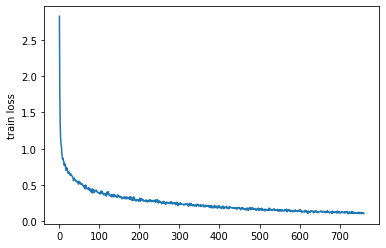

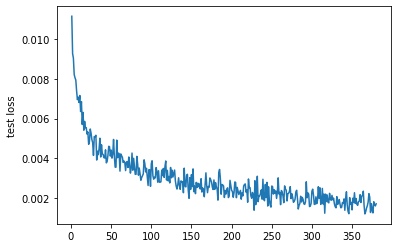

Finished Training


In [11]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/YogaRegNet2_test5.pkl')
train_test2(model.to(device),40,64)

[1,   64] loss:0.116
[1,  128] loss:0.090
Test set: Average loss: 0.0017
[2,   64] loss:0.113
[2,  128] loss:0.106
Test set: Average loss: 0.0013
[3,   64] loss:0.104
[3,  128] loss:0.103
Test set: Average loss: 0.0019
[4,   64] loss:0.115
[4,  128] loss:0.115
Test set: Average loss: 0.0017
[5,   64] loss:0.109
[5,  128] loss:0.125
Test set: Average loss: 0.0017
[6,   64] loss:0.103
[6,  128] loss:0.102
Test set: Average loss: 0.0024
[7,   64] loss:0.110
[7,  128] loss:0.120
Test set: Average loss: 0.0012
[8,   64] loss:0.112
[8,  128] loss:0.114
Test set: Average loss: 0.0020
[9,   64] loss:0.100
[9,  128] loss:0.117
Test set: Average loss: 0.0019
[10,   64] loss:0.114
[10,  128] loss:0.101
Test set: Average loss: 0.0021
[11,   64] loss:0.098
[11,  128] loss:0.108
Test set: Average loss: 0.0021
[12,   64] loss:0.109
[12,  128] loss:0.114
Test set: Average loss: 0.0017
[13,   64] loss:0.111
[13,  128] loss:0.099
Test set: Average loss: 0.0015
[14,   64] loss:0.109
[14,  128] loss:0.114

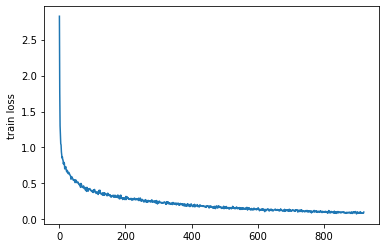

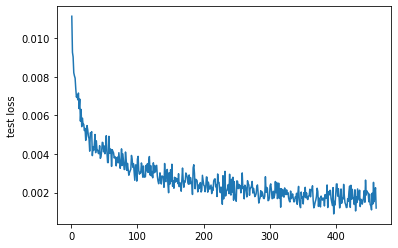

Finished Training


In [13]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/YogaRegNet2_test5.pkl')
train_test2(model.to(device),80,64)

[1,   64] loss:0.084
[1,  128] loss:0.098
Test set: Average loss: 0.0018
[2,   64] loss:0.085
[2,  128] loss:0.083
Test set: Average loss: 0.0013
[3,   64] loss:0.098
[3,  128] loss:0.086
Test set: Average loss: 0.0012
[4,   64] loss:0.089
[4,  128] loss:0.093
Test set: Average loss: 0.0019
[5,   64] loss:0.085
[5,  128] loss:0.084
Test set: Average loss: 0.0012
[6,   64] loss:0.096
[6,  128] loss:0.083
Test set: Average loss: 0.0013
[7,   64] loss:0.091
[7,  128] loss:0.087
Test set: Average loss: 0.0019
[8,   64] loss:0.090
[8,  128] loss:0.080
Test set: Average loss: 0.0013
[9,   64] loss:0.089
[9,  128] loss:0.080
Test set: Average loss: 0.0018
[10,   64] loss:0.095
[10,  128] loss:0.090
Test set: Average loss: 0.0012
[11,   64] loss:0.090
[11,  128] loss:0.097
Test set: Average loss: 0.0015
[12,   64] loss:0.093
[12,  128] loss:0.081
Test set: Average loss: 0.0019
[13,   64] loss:0.074
[13,  128] loss:0.100
Test set: Average loss: 0.0017
[14,   64] loss:0.097
[14,  128] loss:0.087

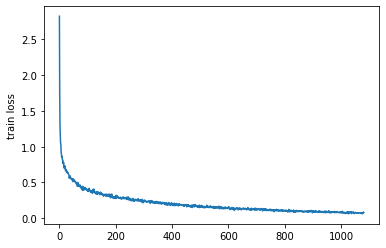

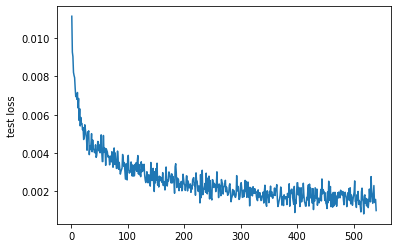

Finished Training


In [14]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/YogaRegNet2_test5.pkl')
train_test2(model.to(device),80,64)

In [15]:
device = torch.device('cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/YogaRegNet2_test5.pkl')
model = model.to(device)
print("测试精度如下：")
test(model)

测试精度如下：
测试集精度为：95%
测试集中下犬式图片的预测精度为：100%
测试集中女神式图片的预测精度为：88%
测试集中低位眼镜蛇式图片的预测精度为：98%
测试集中树式图片的预测精度为：95%
测试集中战士二式图片的预测精度为：93%
混淆矩阵为：
col_0  0.0  1.0  2.0  3.0  4.0
row_0                         
0       72    0    0    0    0
1        0   52    2    1    4
2        0    1   72    0    0
3        0    1    0   60    2
4        0    4    0    0   56
